# Baseline v3.3 — FILTER + Conditional Gain + Multi-band Classifier

Notebook hiện thực đúng pipeline trong `pipeline.png`:

`mixture → FILTER → Conditional Gain (Energy/SNR-aware) → Log-Mel (Low/Mid/High) → CNN → BiLSTM → Attention → Cross-band Gating → 21 nhãn`

Classifier không dùng InstanceNorm/LayerNorm/CMVN hoặc BatchNorm trên Log-Mel; `log(g)` và SNR ước lượng được nối trực tiếp vào cross-band gate và classification head để tránh DSP leakage.

Chiến lược huấn luyện gồm ba stage độc lập:

1. **Stage 1:** huấn luyện FILTER với target là scaled oracle noise.
2. **Stage 2:** đóng băng FILTER, huấn luyện classifier 50/50 trên scaled oracle và noise ước lượng để giảm domain shift.
3. **Stage 3:** fine-tune end-to-end trên mixture.

Đổi `CONFIG["input_mode"]` thành `raw_oracle`, `scaled_oracle`, hoặc `mixture` để chạy ba baseline ở mục 3 của sơ đồ. Với các mode này notebook chỉ chạy Stage 2.


In [1]:
# CELL: imports_and_config
import ast
import hashlib
import json
import math
import random
import shutil
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import soundfile as sf
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchaudio
from IPython.display import display
from sklearn.metrics import average_precision_score, f1_score, precision_recall_fscore_support
from torch.utils.data import DataLoader, Dataset

SELECTED = [137, 300, 0, 72, 138, 111, 307, 73, 288, 396, 98,
            195, 506, 329, 343, 164, 99, 328, 189, 335, 161]
SR, CLIP_S = 16_000, 5.0
N_FFT, WIN, HOP, N_MELS = 512, 512, 160, 64

CONFIG = {
    "seed": 2026,
    "data_root": "/kaggle/input/datasets/truongvp/21-labels/21_labels_dataset",
    "output_dir": "/kaggle/working/runs/baseline_v3_3",
    "batch_size": 16,
    "workers": 2,
    "learning_rate": 3e-4,
    "stage1_epochs": 20,
    "stage2_epochs": 40,
    "stage3_epochs": 20,
    "mrstft_sc_weight": 1.0,
    "mrstft_logmag_weight": 1.0,
    "alpha_filter": 0.05,
    "beta_cls": 1.0,
    "stage3_lr_scale": 0.1,
    "early_stopping_patience": 8,
    "input_mode": "filtered",  # filtered | scaled_oracle | raw_oracle | mixture
    "stages": None,             # None = tự suy ra; ví dụ [3] để resume riêng Stage 3
    "stage2_input_mode": "mixed", # mixed | filtered | scaled_oracle
    "stage2_oracle_weight": 0.5, # mixed loss: 50% oracle + 50% FILTER frozen
    "adaptive_gain": True,
    "conditional_gain_mode": "sigmoid", # sigmoid | soft_threshold
    "snr_threshold_db": 10.0,              # bắt đầu vùng High SNR
    "snr_temperature_db": 2.0,            # độ mượt của sigmoid
    "gain_max_db": 12.0,                  # gain tuyến tính tối đa ≈ 3.98
    "pos_weight_mode": "sqrt", # raw | sqrt | none
    "sliding_window_eval": True,
    "sliding_hop_seconds": 2.5,
    "fusion": "gating",        # gating | mean | concat
    "band_mode": "3band",      # full | 2band | 3band
}

def seed_all(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

assert CONFIG["input_mode"] in {"filtered", "scaled_oracle", "raw_oracle", "mixture"}
assert CONFIG["pos_weight_mode"] in {"raw", "sqrt", "none"}
assert CONFIG["conditional_gain_mode"] in {"sigmoid", "soft_threshold"}
assert CONFIG["snr_temperature_db"] > 0
assert CONFIG["stage2_input_mode"] in {"mixed", "filtered", "scaled_oracle"}
assert 0.0 <= CONFIG["stage2_oracle_weight"] <= 1.0
assert CONFIG["fusion"] in {"gating", "mean", "concat"}
assert CONFIG["band_mode"] in {"full", "2band", "3band"}
if CONFIG["stages"] is not None:
    assert set(CONFIG["stages"]).issubset({1, 2, 3})

seed_all(CONFIG["seed"])
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
if DEVICE.type == "cuda":
    torch.backends.cudnn.benchmark = True

config_hash = hashlib.sha1(json.dumps(CONFIG, sort_keys=True).encode()).hexdigest()[:8]
CONFIG["experiment_name"] = (
    f"{CONFIG['input_mode']}_{CONFIG['band_mode']}_{CONFIG['fusion']}_{config_hash}"
)
CONFIG["output_dir"] = str(Path(CONFIG["output_dir"]) / CONFIG["experiment_name"])
print("Device:", DEVICE)
print("Experiment:", CONFIG["experiment_name"])


Device: cuda
Experiment: filtered_3band_gating_14bc255b


In [2]:
# CELL: dataset_discovery
SPLITS = ("train_single", "validation_single", "test_single")


def is_dataset_root(path):
    path = Path(path)
    return path.is_dir() and all(
        (path / split / "manifest.csv").is_file() for split in SPLITS)


configured_root = Path(CONFIG["data_root"])
candidates = [
    configured_root,
    Path("/kaggle/input/datasets/truongvp/21-labels/21_labels_dataset"),
    Path("/kaggle/input/21-labels/21_labels_dataset2"),
    Path("/kaggle/input/21-labels/21_labels_dataset"),
    Path("/kaggle/input/audioset-vlsp-v2/mixed_audioset_vlsp_v2"),
]
kaggle_input = Path("/kaggle/input")
if kaggle_input.is_dir():
    # Kaggle mount theo /kaggle/input/<dataset-slug>, có thể có thêm một thư mục con.
    for mount in kaggle_input.iterdir():
        if not mount.is_dir():
            continue
        candidates.append(mount)
        candidates.extend(child for child in mount.iterdir() if child.is_dir())

DATA_ROOT = next((path for path in candidates if is_dataset_root(path)), None)
if DATA_ROOT is None:
    mounts = sorted(path.name for path in kaggle_input.iterdir()) if kaggle_input.is_dir() else []
    raise AssertionError(
        f"Không tìm thấy dataset root chứa đủ {SPLITS}. "
        f"Đường dẫn đã cấu hình: {configured_root}. Kaggle mounts hiện có: {mounts}")
CONFIG["data_root"] = str(DATA_ROOT)
print("Resolved dataset root:", DATA_ROOT)

missing = [str(DATA_ROOT / split / "manifest.csv") for split in SPLITS
           if not (DATA_ROOT / split / "manifest.csv").is_file()]
assert not missing, "Thiếu manifest: " + ", ".join(missing)

label_file = DATA_ROOT / "selected_labels.csv"
if label_file.is_file():
    label_info = pd.read_csv(label_file).sort_values("model_index")
    CLASS_NAMES = label_info["display_name"].tolist()
else:
    CLASS_NAMES = [f"label_{index}" for index in SELECTED]
    label_info = pd.DataFrame({"model_index": range(21), "original_index": SELECTED,
                               "display_name": CLASS_NAMES})
assert len(CLASS_NAMES) == len(SELECTED) == 21
display(label_info[["model_index", "original_index", "display_name"]])

summary = []
for split in SPLITS:
    frame = pd.read_csv(DATA_ROOT / split / "manifest.csv")
    summary.append({"split": split, "samples": len(frame),
                    "mixture": len(list((DATA_ROOT / split / "mixture").glob("*.wav"))),
                    "oracle_noise": len(list((DATA_ROOT / split / "oracle_noise").glob("*.wav")))})
display(pd.DataFrame(summary))


Resolved dataset root: /kaggle/input/datasets/truongvp/21-labels/21_labels_dataset


,model_index,original_index,display_name
0,0,137,Music
1,1,300,Vehicle
2,2,0,Speech
3,3,72,Animal
4,4,138,Musical instrument
5,5,111,Bird
6,6,307,Car
7,7,73,"Domestic animals, pets"
8,8,288,Water
9,9,396,Siren


,split,samples,mixture,oracle_noise
0,train_single,18231,18231,18231
1,validation_single,3907,3907,3907
2,test_single,3906,3906,3906


In [3]:
# CELL: dataset
def parse_labels(value):
    if not isinstance(value, str):
        return []
    try:
        return [int(v) for v in ast.literal_eval(value)]
    except (ValueError, SyntaxError, TypeError):
        return [int(v) for v in value.strip("[]() ").split(",") if v.strip()]


def noise_scale_for(row):
    # Dataset hiện tại lưu oracle_noise đã scale nên fallback đúng là 1.0.
    value = row.get("noise_scale", 1.0)
    return 1.0 if pd.isna(value) else float(value)


def read_mono(path):
    x, sr = sf.read(path, dtype="float32", always_2d=True)
    x = torch.from_numpy(x.mean(axis=1))
    return torchaudio.functional.resample(x, sr, SR) if sr != SR else x


def crop_or_pad(x, length, start):
    x = x[start:start + length]
    return F.pad(x, (0, max(0, length - x.numel())))[:length]


class NoiseDataset(Dataset):
    def __init__(self, root, split, train):
        self.root = Path(root) / split
        self.train = train
        self.df = pd.read_csv(self.root / "manifest.csv")
        self.length = int(CLIP_S * SR)
        self.label_pos = {label: i for i, label in enumerate(SELECTED)}

    def __len__(self):
        return len(self.df)

    def load_full(self, i):
        row = self.df.iloc[i]
        sid = row["sample_id"]
        mixture = read_mono(self.root / "mixture" / f"{sid}.wav")
        oracle_raw = read_mono(self.root / "oracle_noise" / f"{sid}.wav")
        available = min(mixture.numel(), oracle_raw.numel())
        mixture, oracle_raw = mixture[:available], oracle_raw[:available]
        target = torch.zeros(len(SELECTED), dtype=torch.float32)
        for label in parse_labels(row["label_indices"]):
            if label in self.label_pos:
                target[self.label_pos[label]] = 1.0
        return (mixture, oracle_raw, noise_scale_for(row), target,
                float(row["target_snr_db"]))

    def __getitem__(self, i):
        mixture, oracle_raw, noise_scale, target, snr = self.load_full(i)
        available = min(mixture.numel(), oracle_raw.numel())
        start = (random.randint(0, max(0, available - self.length)) if self.train
                 else max(0, (available - self.length) // 2))
        return (crop_or_pad(mixture, self.length, start),
                crop_or_pad(oracle_raw, self.length, start),
                torch.tensor(noise_scale, dtype=torch.float32), target, snr)


In [4]:
# CELL: mixture_sanity_check
# Xác minh: mixture ≈ clean + noise_scale * oracle_raw trên 32 mẫu train.
sanity_df = pd.read_csv(DATA_ROOT / "train_single" / "manifest.csv")
sanity_rows = sanity_df.sample(min(32, len(sanity_df)), random_state=CONFIG["seed"])
errors = []
for _, row in sanity_rows.iterrows():
    sid = row["sample_id"]
    mixture = read_mono(DATA_ROOT / "train_single" / "mixture" / f"{sid}.wav")
    clean = read_mono(DATA_ROOT / "train_single" / "clean" / f"{sid}.wav")
    oracle = read_mono(DATA_ROOT / "train_single" / "oracle_noise" / f"{sid}.wav")
    length = min(mixture.numel(), clean.numel(), oracle.numel())
    relative_error = torch.linalg.vector_norm(
        mixture[:length] - clean[:length] - noise_scale_for(row) * oracle[:length]
    ) / torch.linalg.vector_norm(mixture[:length]).clamp_min(1e-8)
    errors.append((sid, float(relative_error)))
worst_sid, worst_error = max(errors, key=lambda item: item[1])
assert worst_error < 1e-2, (
    f"Mixture assertion hỏng tại {worst_sid}: relative error={worst_error:.6f}. "
    "Hãy kiểm tra ngữ nghĩa/cột noise_scale trong manifest."
)
print(f"Mixture sanity check OK — max relative error: {worst_error:.6f}")


Mixture sanity check OK — max relative error: 0.000153


In [5]:
# CELL: dataloaders
train_ds = NoiseDataset(DATA_ROOT, "train_single", True)
val_ds = NoiseDataset(DATA_ROOT, "validation_single", False)
test_ds = NoiseDataset(DATA_ROOT, "test_single", False)

loader_args = dict(batch_size=CONFIG["batch_size"], num_workers=CONFIG["workers"],
                   pin_memory=DEVICE.type == "cuda",
                   persistent_workers=CONFIG["workers"] > 0)
train_loader = DataLoader(train_ds, shuffle=True, drop_last=True, **loader_args)
val_loader = DataLoader(val_ds, shuffle=False, **loader_args)
test_loader = DataLoader(test_ds, shuffle=False, **loader_args)

label_matrix = np.zeros((len(train_ds), len(SELECTED)), dtype=np.float32)
for row_i, value in enumerate(train_ds.df["label_indices"]):
    for label in parse_labels(value):
        if label in train_ds.label_pos:
            label_matrix[row_i, train_ds.label_pos[label]] = 1.0
positives = label_matrix.sum(0)
raw_pos_weight = torch.tensor(
    (len(train_ds) - positives) / np.maximum(positives, 1),
    dtype=torch.float32, device=DEVICE).clamp(max=20)
if CONFIG["pos_weight_mode"] == "raw":
    pos_weight = raw_pos_weight
elif CONFIG["pos_weight_mode"] == "sqrt":
    pos_weight = raw_pos_weight.sqrt()
else:
    pos_weight = None
print(f"Train/Val/Test: {len(train_ds):,}/{len(val_ds):,}/{len(test_ds):,}")


Train/Val/Test: 18,231/3,907/3,906


In [6]:
# CELL: model
class ConvBlock(nn.Module):
    def __init__(self, cin, cout):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(cin, cout, 3, padding=1, bias=False), nn.BatchNorm2d(cout), nn.SiLU(),
            nn.Conv2d(cout, cout, 3, padding=1, bias=False), nn.BatchNorm2d(cout), nn.SiLU())

    def forward(self, x):
        return self.net(x)


class FeatureConvBlock(nn.Module):
    """Classifier block không normalization để bảo toàn dịch mức log(g)."""
    def __init__(self, cin, cout):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(cin, cout, 3, padding=1), nn.SiLU(),
            nn.Conv2d(cout, cout, 3, padding=1), nn.SiLU())

    def forward(self, x):
        return self.net(x)


class NoiseMaskUNet(nn.Module):
    """FILTER: U-Net nhỏ dự đoán bounded complex ratio mask."""
    def __init__(self):
        super().__init__()
        self.e1, self.e2, self.e3 = ConvBlock(2, 16), ConvBlock(16, 32), ConvBlock(32, 64)
        self.pool = nn.MaxPool2d(2)
        self.up2, self.d2 = nn.ConvTranspose2d(64, 32, 2, 2), ConvBlock(64, 32)
        self.up1, self.d1 = nn.ConvTranspose2d(32, 16, 2, 2), ConvBlock(32, 16)
        self.out = nn.Conv2d(16, 2, 1)

    @staticmethod
    def _fit(x, ref):
        return F.interpolate(x, size=ref.shape[-2:], mode="bilinear", align_corners=False)

    def forward(self, x):
        a = self.e1(x)
        b = self.e2(self.pool(a))
        z = self.e3(self.pool(b))
        z = self.d2(torch.cat([self._fit(self.up2(z), b), b], 1))
        z = self.d1(torch.cat([self._fit(self.up1(z), a), a], 1))
        return torch.tanh(self.out(z))


class BandEncoder(nn.Module):
    """CNN per-band → BiLSTM → temporal attention."""
    def __init__(self, hidden=64, embedding=128):
        super().__init__()
        self.cnn = nn.Sequential(
            FeatureConvBlock(1, 16), nn.MaxPool2d((1, 2)),
            FeatureConvBlock(16, 32), nn.MaxPool2d((1, 2)),
            nn.AdaptiveAvgPool2d((4, None)))
        self.rnn = nn.LSTM(32 * 4, hidden, batch_first=True, bidirectional=True)
        self.attention = nn.Linear(hidden * 2, 1)
        self.projection = nn.Sequential(nn.Dropout(0.2), nn.Linear(hidden * 2, embedding))

    def forward(self, x):
        x = self.cnn(x).permute(0, 3, 1, 2).flatten(2)
        x, _ = self.rnn(x)
        x = (torch.softmax(self.attention(x), dim=1) * x).sum(dim=1)
        return self.projection(x)


BAND_LAYOUTS = {
    "full": ((0, 64),),
    "2band": ((0, 40), (32, 64)),
    "3band": ((0, 32), (32, 49), (49, 64)),
}


class BaselineV3(nn.Module):
    def __init__(self, n_classes=21, band_mode="3band", fusion="gating",
                 adaptive_gain=True, gain_max_db=12.0,
                 conditional_gain_mode="sigmoid", snr_threshold_db=10.0,
                 snr_temperature_db=2.0):
        super().__init__()
        self.fusion = fusion
        self.adaptive_gain = adaptive_gain
        self.conditional_gain_mode = conditional_gain_mode
        self.snr_threshold_db = float(snr_threshold_db)
        self.snr_temperature_db = float(snr_temperature_db)
        self.gain_max = 10.0 ** (gain_max_db / 20.0)
        if conditional_gain_mode not in {"sigmoid", "soft_threshold"}:
            raise ValueError(f"Unknown conditional_gain_mode: {conditional_gain_mode}")
        if self.snr_temperature_db <= 0:
            raise ValueError("snr_temperature_db must be positive")
        self.register_buffer("window", torch.hann_window(WIN), persistent=False)
        self.filter = NoiseMaskUNet()
        self.mel = torchaudio.transforms.MelScale(
            N_MELS, SR, 20, SR // 2, N_FFT // 2 + 1, mel_scale="htk")
        self.bands = BAND_LAYOUTS[band_mode]
        self.encoders = nn.ModuleList(BandEncoder() for _ in self.bands)
        self.condition_dim = 2  # [log(g), SNR_estimate / 20]
        self.gate = nn.Linear(128 * len(self.bands) + self.condition_dim, len(self.bands))
        head_dim = 128 * len(self.bands) if fusion == "concat" else 128
        self.head = nn.Linear(head_dim + self.condition_dim, n_classes)

    def stft(self, waveform):
        return torch.stft(waveform, N_FFT, HOP, WIN, self.window, return_complex=True)

    def istft(self, spectrum, length):
        return torch.istft(spectrum, N_FFT, HOP, WIN, self.window, length=length)

    def estimate_noise(self, mixture):
        mixture_spec = self.stft(mixture)
        mask_ri = self.filter(torch.view_as_real(mixture_spec).permute(0, 3, 1, 2))
        mask = torch.complex(mask_ri[:, 0], mask_ri[:, 1])
        return mask * mixture_spec, mask, mixture_spec

    def estimate_conditional_gain(self, noise_spec, mixture_spec):
        # Phần dư x - n_hat là proxy của speech; không cần target_snr_db lúc inference.
        dims = tuple(range(1, noise_spec.ndim))
        noise_energy = noise_spec.abs().square().mean(dims, keepdim=True)
        speech_energy = (mixture_spec - noise_spec).abs().square().mean(
            dims, keepdim=True)
        snr_estimate_db = 10.0 * torch.log10(
            (speech_energy + 1e-8) / (noise_energy + 1e-8))
        if self.conditional_gain_mode == "sigmoid":
            high_snr_gate = torch.sigmoid(
                (snr_estimate_db - self.snr_threshold_db) / self.snr_temperature_db)
            gain = 1.0 + (self.gain_max - 1.0) * high_snr_gate
        else:
            # Đưa noise ở vùng High SNR về gần E_target ứng với SNR threshold.
            target_noise_energy = speech_energy / (10.0 ** (self.snr_threshold_db / 10.0))
            requested_gain = torch.sqrt(
                target_noise_energy / (noise_energy + 1e-8)).clamp(1.0, self.gain_max)
            gain = torch.where(snr_estimate_db > self.snr_threshold_db,
                               requested_gain, torch.ones_like(requested_gain))
        # Chặn đường tắt gradient: FILTER không thể giảm energy để tự nhận gain lớn hơn.
        return gain.detach(), snr_estimate_db.detach()

    def condition_noise(self, noise_spec, mixture_spec):
        if self.adaptive_gain:
            gain, snr_estimate_db = self.estimate_conditional_gain(noise_spec, mixture_spec)
            conditioned_spec = noise_spec * gain
            condition = torch.cat([
                torch.log(gain.clamp_min(1e-8)).flatten(1),
                (snr_estimate_db / 20.0).clamp(-2.0, 2.0).flatten(1),
            ], dim=1)
        else:
            conditioned_spec = noise_spec
            condition = noise_spec.real.new_zeros((len(noise_spec), self.condition_dim))
        return conditioned_spec, condition

    def apply_adaptive_gain(self, noise_spec, mixture_spec):
        return self.condition_noise(noise_spec, mixture_spec)[0]

    def forward(self, mixture, reference=None, input_mode="filtered"):
        mixture_spec = self.stft(mixture)
        if input_mode == "filtered":
            raw_estimate, mask, _ = self.estimate_noise(mixture)
            classifier_spec, condition = self.condition_noise(raw_estimate, mixture_spec)
            reconstruction_spec = raw_estimate
        elif input_mode in {"scaled_oracle", "raw_oracle"}:
            if reference is None:
                raise ValueError(f"reference waveform is required for input_mode={input_mode!r}")
            reference_spec = self.stft(reference)
            classifier_spec, condition = self.condition_noise(reference_spec, mixture_spec)
            reconstruction_spec, mask = reference_spec, None
        elif input_mode == "mixture":
            classifier_spec = reconstruction_spec = mixture_spec
            mask = None
            condition = mixture_spec.real.new_zeros((len(mixture_spec), self.condition_dim))
        else:
            raise ValueError(f"Unknown input_mode: {input_mode}")

        log_mel = torch.log(self.mel(classifier_spec.abs().square()) + 1e-6).unsqueeze(1)
        embeddings = [encoder(log_mel[:, :, low:high])
                      for encoder, (low, high) in zip(self.encoders, self.bands)]
        if self.fusion == "gating":
            gate_input = torch.cat([*embeddings, condition], dim=1)
            weights = torch.softmax(self.gate(gate_input), dim=1)
            fused = sum(weights[:, i:i + 1] * value for i, value in enumerate(embeddings))
        elif self.fusion == "mean":
            weights = log_mel.new_full((len(log_mel), len(embeddings)), 1.0 / len(embeddings))
            fused = torch.stack(embeddings, dim=1).mean(dim=1)
        else:
            weights = log_mel.new_full((len(log_mel), len(embeddings)), 1.0 / len(embeddings))
            fused = torch.cat(embeddings, dim=1)
        fused = torch.cat([fused, condition], dim=1)
        return self.head(fused), reconstruction_spec, mask, weights


In [7]:
# CELL: objectives_and_metrics
MRSTFT_RESOLUTIONS = ((256, 64, 256), (512, 160, 512), (1024, 256, 1024))


def multi_resolution_stft_loss(estimate_wave, target_wave, sc_weight=1.0,
                               logmag_weight=1.0, eps=1e-7):
    spectral_convergence, log_magnitude = [], []
    for n_fft, hop_length, win_length in MRSTFT_RESOLUTIONS:
        window = torch.hann_window(win_length, device=estimate_wave.device,
                                   dtype=estimate_wave.dtype)
        estimate_mag = torch.stft(
            estimate_wave, n_fft, hop_length, win_length, window,
            return_complex=True).abs().clamp_min(eps)
        target_mag = torch.stft(
            target_wave, n_fft, hop_length, win_length, window,
            return_complex=True).abs().clamp_min(eps)
        numerator = (target_mag - estimate_mag).flatten(1).norm(dim=1)
        denominator = target_mag.flatten(1).norm(dim=1).clamp_min(eps)
        spectral_convergence.append((numerator / denominator).mean())
        log_magnitude.append(
            (torch.log(target_mag) - torch.log(estimate_mag)).abs().mean())
    sc_loss = torch.stack(spectral_convergence).mean()
    logmag_loss = torch.stack(log_magnitude).mean()
    return sc_weight * sc_loss + logmag_weight * logmag_loss, sc_loss, logmag_loss


def filter_objective(model, estimate_spec, target_wave):
    # MR-STFT chạy float32 để ổn định cả ISTFT và nhiều độ phân giải phổ.
    with torch.autocast(DEVICE.type, enabled=False):
        estimate_spec = estimate_spec.to(torch.complex64)
        target_wave = target_wave.float()
        estimate_wave = model.istft(estimate_spec, length=target_wave.shape[-1]).float()
        loss, sc_loss, logmag_loss = multi_resolution_stft_loss(
            estimate_wave, target_wave, CONFIG["mrstft_sc_weight"],
            CONFIG["mrstft_logmag_weight"])
    return loss, sc_loss.detach(), logmag_loss.detach()


def tune_thresholds(y, probabilities):
    thresholds = np.full(y.shape[1], 0.5)
    for c in range(y.shape[1]):
        candidates = [(f1_score(y[:, c], probabilities[:, c] >= t, zero_division=0), t)
                      for t in np.arange(0.10, 0.91, 0.05)]
        thresholds[c] = max(candidates)[1]
    return thresholds


def metrics(y, probabilities, thresholds):
    prediction = probabilities >= thresholds
    return {
        "macro_f1": float(f1_score(y, prediction, average="macro", zero_division=0)),
        "micro_f1": float(f1_score(y, prediction, average="micro", zero_division=0)),
        "mAP": float(average_precision_score(y, probabilities, average="macro")),
    }


def reference_for_mode(oracle_raw, noise_scale, input_mode):
    if input_mode == "scaled_oracle":
        return oracle_raw * noise_scale.view(-1, 1)
    if input_mode == "raw_oracle":
        return oracle_raw
    return None


def make_paired_windows(mixture, oracle, length, hop):
    available = min(mixture.numel(), oracle.numel())
    if available <= length:
        return (crop_or_pad(mixture, length, 0).unsqueeze(0),
                crop_or_pad(oracle, length, 0).unsqueeze(0))
    starts = list(range(0, available - length + 1, hop))
    if starts[-1] != available - length:
        starts.append(available - length)
    return (torch.stack([crop_or_pad(mixture, length, s) for s in starts]),
            torch.stack([crop_or_pad(oracle, length, s) for s in starts]))


@torch.inference_mode()
def predict(model, loader, device, input_mode, sliding=False, hop_seconds=2.5):
    model.eval()
    targets, probabilities, snrs = [], [], []
    if not sliding:
        for mixture, oracle_raw, noise_scale, target, snr in loader:
            mixture = mixture.to(device)
            oracle_raw = oracle_raw.to(device)
            noise_scale = noise_scale.to(device)
            reference = reference_for_mode(oracle_raw, noise_scale, input_mode)
            logits, *_ = model(mixture, reference, input_mode)
            targets.append(target.numpy())
            probabilities.append(logits.sigmoid().cpu().numpy())
            snrs.append(snr.numpy())
    else:
        dataset = loader.dataset
        hop = max(1, int(hop_seconds * SR))
        for i in range(len(dataset)):
            mixture, oracle_raw, noise_scale, target, snr = dataset.load_full(i)
            mixture_w, oracle_w = make_paired_windows(mixture, oracle_raw, dataset.length, hop)
            window_probabilities = []
            for start in range(0, len(mixture_w), loader.batch_size):
                end = start + loader.batch_size
                mix_batch = mixture_w[start:end].to(device)
                oracle_batch = oracle_w[start:end].to(device)
                scales = torch.full((len(mix_batch),), noise_scale, device=device)
                reference = reference_for_mode(oracle_batch, scales, input_mode)
                logits, *_ = model(mix_batch, reference, input_mode)
                window_probabilities.append(logits.sigmoid().cpu())
            targets.append(target.numpy()[None])
            probabilities.append(torch.cat(window_probabilities).mean(0).numpy()[None])
            snrs.append(np.asarray([snr]))
    return np.concatenate(targets), np.concatenate(probabilities), np.concatenate(snrs)


In [8]:
# CELL: training_stages
def save_checkpoint(path, model, stage, epoch, val_metrics=None, thresholds=None):
    torch.save({
        "model": model.state_dict(), "stage": stage, "epoch": epoch,
        "val_metrics": val_metrics, "thresholds": thresholds,
        "selected_indices": SELECTED, "class_names": CLASS_NAMES, "config": CONFIG,
    }, path)


def load_checkpoint(path, model):
    if not Path(path).is_file():
        raise FileNotFoundError(f"Không có checkpoint tiên quyết: {path}")
    checkpoint = torch.load(path, map_location=DEVICE, weights_only=False)
    model.load_state_dict(checkpoint["model"])
    return checkpoint


def append_history(record):
    HISTORY.append(record)
    with HISTORY_PATH.open("a", encoding="utf8") as stream:
        stream.write(json.dumps(record) + "\n")


@torch.inference_mode()
def validate_filter(model, loader):
    model.eval()
    sums = np.zeros(3, dtype=np.float64)
    seen = 0
    for mixture, oracle_raw, noise_scale, _, _ in loader:
        mixture = mixture.to(DEVICE)
        scaled = oracle_raw.to(DEVICE) * noise_scale.to(DEVICE).view(-1, 1)
        estimate, _, _ = model.estimate_noise(mixture)
        loss, sc_loss, logmag_loss = filter_objective(model, estimate, scaled)
        sums += np.array([loss.item(), sc_loss.item(), logmag_loss.item()]) * len(mixture)
        seen += len(mixture)
    return sums / seen


def run_stage1_filter(model):
    model.filter.requires_grad_(True)
    for name, parameter in model.named_parameters():
        if not name.startswith("filter."):
            parameter.requires_grad_(False)
    optimizer = torch.optim.AdamW(model.filter.parameters(), lr=CONFIG["learning_rate"],
                                  weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", patience=2)
    scaler = torch.amp.GradScaler("cuda", enabled=DEVICE.type == "cuda")
    best, bad_epochs = math.inf, 0
    for epoch in range(1, CONFIG["stage1_epochs"] + 1):
        model.filter.train()
        sums = np.zeros(3, dtype=np.float64)
        seen, started = 0, time.time()
        for mixture, oracle_raw, noise_scale, _, _ in train_loader:
            mixture = mixture.to(DEVICE, non_blocking=True)
            scaled = oracle_raw.to(DEVICE, non_blocking=True) * noise_scale.to(
                DEVICE, non_blocking=True).view(-1, 1)
            optimizer.zero_grad(set_to_none=True)
            with torch.autocast(DEVICE.type, enabled=DEVICE.type == "cuda"):
                estimate, _, _ = model.estimate_noise(mixture)
            loss, sc_loss, logmag_loss = filter_objective(model, estimate, scaled)
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            nn.utils.clip_grad_norm_(model.filter.parameters(), 5.0)
            scaler.step(optimizer)
            scaler.update()
            sums += np.array([loss.item(), sc_loss.item(), logmag_loss.item()]) * len(mixture)
            seen += len(mixture)
        val_loss, val_sc, val_logmag = validate_filter(model, val_loader)
        scheduler.step(val_loss)
        record = {"stage": 1, "epoch": epoch, "train_filter_loss": sums[0] / seen,
                  "train_spectral_convergence": sums[1] / seen,
                  "train_logmag_loss": sums[2] / seen,
                  "val_filter_loss": val_loss, "val_spectral_convergence": val_sc,
                  "val_logmag_loss": val_logmag,
                  "lr": optimizer.param_groups[0]["lr"],
                  "seconds": time.time() - started}
        append_history(record)
        improved = val_loss < best - 1e-4
        if improved:
            best, bad_epochs = val_loss, 0
            save_checkpoint(OUT_DIR / "stage1_filter.pt", model, 1, epoch)
        else:
            bad_epochs += 1
        print(f"Stage 1 | {epoch:02d} | MR-STFT {val_loss:.4f} | SC {val_sc:.4f}"
              + (" <- best" if improved else ""))
        if bad_epochs >= CONFIG["early_stopping_patience"]:
            break
    load_checkpoint(OUT_DIR / "stage1_filter.pt", model)


def run_stage2_classifier(model, input_mode="mixed"):
    if input_mode not in {"mixed", "filtered", "scaled_oracle",
                          "raw_oracle", "mixture"}:
        raise ValueError(f"Invalid Stage 2 input mode: {input_mode}")
    for name, parameter in model.named_parameters():
        parameter.requires_grad_(not name.startswith("filter."))
    parameters = [p for name, p in model.named_parameters()
                  if not name.startswith("filter.")]
    optimizer = torch.optim.AdamW(parameters, lr=CONFIG["learning_rate"], weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="max", patience=2)
    scaler = torch.amp.GradScaler("cuda", enabled=DEVICE.type == "cuda")
    best, bad_epochs = -1.0, 0
    for epoch in range(1, CONFIG["stage2_epochs"] + 1):
        model.train()
        model.filter.eval()  # đóng băng cả BatchNorm running statistics
        total_loss, seen, started = 0.0, 0, time.time()
        for mixture, oracle_raw, noise_scale, target, _ in train_loader:
            mixture = mixture.to(DEVICE, non_blocking=True)
            oracle_raw = oracle_raw.to(DEVICE, non_blocking=True)
            noise_scale = noise_scale.to(DEVICE, non_blocking=True)
            target = target.to(DEVICE, non_blocking=True)
            optimizer.zero_grad(set_to_none=True)
            with torch.autocast(DEVICE.type, enabled=DEVICE.type == "cuda"):
                if input_mode == "mixed":
                    scaled_oracle = oracle_raw * noise_scale.view(-1, 1)
                    oracle_logits, *_ = model(mixture, scaled_oracle, "scaled_oracle")
                    filtered_logits, *_ = model(mixture, None, "filtered")
                    oracle_loss = F.binary_cross_entropy_with_logits(
                        oracle_logits, target, pos_weight=pos_weight)
                    filtered_loss = F.binary_cross_entropy_with_logits(
                        filtered_logits, target, pos_weight=pos_weight)
                    oracle_weight = CONFIG["stage2_oracle_weight"]
                    loss = oracle_weight * oracle_loss + (1.0 - oracle_weight) * filtered_loss
                else:
                    reference = reference_for_mode(oracle_raw, noise_scale, input_mode)
                    logits, *_ = model(mixture, reference, input_mode)
                    loss = F.binary_cross_entropy_with_logits(
                        logits, target, pos_weight=pos_weight)
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            nn.utils.clip_grad_norm_(parameters, 5.0)
            scaler.step(optimizer)
            scaler.update()
            total_loss += loss.item() * len(target)
            seen += len(target)
        # Mixed training luôn chọn checkpoint trên domain triển khai: FILTER output.
        val_mode = "filtered" if input_mode == "mixed" else input_mode
        val_y, val_prob, _ = predict(model, val_loader, DEVICE, val_mode,
                                     CONFIG["sliding_window_eval"],
                                     CONFIG["sliding_hop_seconds"])
        thresholds = tune_thresholds(val_y, val_prob)
        val_metrics = metrics(val_y, val_prob, thresholds)
        scheduler.step(val_metrics["macro_f1"])
        record = {"stage": 2, "epoch": epoch, "input_mode": input_mode,
                  "validation_input_mode": val_mode,
                  "train_classification_loss": total_loss / seen,
                  **{f"val_{key}": value for key, value in val_metrics.items()},
                  "lr": optimizer.param_groups[0]["lr"], "seconds": time.time() - started}
        append_history(record)
        improved = val_metrics["macro_f1"] > best + 1e-3
        if improved:
            best, bad_epochs = val_metrics["macro_f1"], 0
            save_checkpoint(OUT_DIR / "stage2_best.pt", model, 2, epoch,
                            val_metrics, thresholds)
        else:
            bad_epochs += 1
        print(f"Stage 2 | {epoch:02d} | val macro-F1 {val_metrics['macro_f1']:.4f}"
              + (" <- best" if improved else ""))
        if bad_epochs >= CONFIG["early_stopping_patience"]:
            break
    checkpoint = load_checkpoint(OUT_DIR / "stage2_best.pt", model)
    if input_mode == "raw_oracle" and "noise_scale" not in train_ds.df.columns:
        print("Cảnh báo: raw_oracle = scaled_oracle vì manifest không có cột noise_scale.")
    return checkpoint


def run_stage3_finetune(model):
    load_checkpoint(OUT_DIR / "stage2_best.pt", model)
    model.requires_grad_(True)
    optimizer = torch.optim.AdamW(model.parameters(),
                                  lr=CONFIG["learning_rate"] * CONFIG["stage3_lr_scale"],
                                  weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="max", patience=2)
    scaler = torch.amp.GradScaler("cuda", enabled=DEVICE.type == "cuda")
    best, bad_epochs = -1.0, 0
    for epoch in range(1, CONFIG["stage3_epochs"] + 1):
        model.train()
        sums = np.zeros(4, dtype=np.float64)
        seen, started = 0, time.time()
        for mixture, oracle_raw, noise_scale, target, _ in train_loader:
            mixture = mixture.to(DEVICE, non_blocking=True)
            scaled = oracle_raw.to(DEVICE, non_blocking=True) * noise_scale.to(
                DEVICE, non_blocking=True).view(-1, 1)
            target = target.to(DEVICE, non_blocking=True)
            optimizer.zero_grad(set_to_none=True)
            with torch.autocast(DEVICE.type, enabled=DEVICE.type == "cuda"):
                logits, estimate, *_ = model(mixture, None, "filtered")
                cls_loss = F.binary_cross_entropy_with_logits(logits, target,
                                                              pos_weight=pos_weight)
            filter_loss, sc_loss, logmag_loss = filter_objective(model, estimate, scaled)
            total = CONFIG["alpha_filter"] * filter_loss + CONFIG["beta_cls"] * cls_loss
            scaler.scale(total).backward()
            scaler.unscale_(optimizer)
            nn.utils.clip_grad_norm_(model.parameters(), 5.0)
            scaler.step(optimizer)
            scaler.update()
            sums += np.array([total.item(), cls_loss.item(), sc_loss.item(), logmag_loss.item()]) * len(target)
            seen += len(target)
        val_y, val_prob, _ = predict(model, val_loader, DEVICE, "filtered",
                                     CONFIG["sliding_window_eval"],
                                     CONFIG["sliding_hop_seconds"])
        thresholds = tune_thresholds(val_y, val_prob)
        val_metrics = metrics(val_y, val_prob, thresholds)
        scheduler.step(val_metrics["macro_f1"])
        record = {"stage": 3, "epoch": epoch, "train_total_loss": sums[0] / seen,
                  "train_classification_loss": sums[1] / seen,
                  "train_spectral_convergence": sums[2] / seen,
                  "train_logmag_loss": sums[3] / seen,
                  **{f"val_{key}": value for key, value in val_metrics.items()},
                  "lr": optimizer.param_groups[0]["lr"], "seconds": time.time() - started}
        append_history(record)
        improved = val_metrics["macro_f1"] > best + 1e-3
        if improved:
            best, bad_epochs = val_metrics["macro_f1"], 0
            save_checkpoint(OUT_DIR / "stage3_best.pt", model, 3, epoch,
                            val_metrics, thresholds)
            shutil.copy2(OUT_DIR / "stage3_best.pt", OUT_DIR / "best.pt")
        else:
            bad_epochs += 1
        print(f"Stage 3 | {epoch:02d} | val macro-F1 {val_metrics['macro_f1']:.4f}"
              + (" <- best" if improved else ""))
        if bad_epochs >= CONFIG["early_stopping_patience"]:
            break
    return load_checkpoint(OUT_DIR / "stage3_best.pt", model)


In [9]:
# CELL: run_training
OUT_DIR = Path(CONFIG["output_dir"])
OUT_DIR.mkdir(parents=True, exist_ok=True)
(OUT_DIR / "config.json").write_text(json.dumps(CONFIG, indent=2), encoding="utf8")
HISTORY, HISTORY_PATH = [], OUT_DIR / "history.jsonl"
HISTORY_PATH.write_text("", encoding="utf8")

model = BaselineV3(
    n_classes=len(SELECTED), band_mode=CONFIG["band_mode"], fusion=CONFIG["fusion"],
    adaptive_gain=CONFIG["adaptive_gain"], gain_max_db=CONFIG["gain_max_db"],
    conditional_gain_mode=CONFIG["conditional_gain_mode"],
    snr_threshold_db=CONFIG["snr_threshold_db"],
    snr_temperature_db=CONFIG["snr_temperature_db"],
).to(DEVICE)
stages = CONFIG["stages"]
if stages is None:
    stages = [1, 2, 3] if CONFIG["input_mode"] == "filtered" else [2]

if 1 in stages:
    run_stage1_filter(model)
elif 2 in stages and CONFIG["input_mode"] == "filtered":
    load_checkpoint(OUT_DIR / "stage1_filter.pt", model)

stage2_mode = (CONFIG["stage2_input_mode"]
               if CONFIG["input_mode"] == "filtered" else CONFIG["input_mode"])
if 2 in stages:
    run_stage2_classifier(model, stage2_mode)
    if CONFIG["input_mode"] != "filtered":
        shutil.copy2(OUT_DIR / "stage2_best.pt", OUT_DIR / "best.pt")

if 3 in stages:
    if CONFIG["input_mode"] != "filtered":
        raise ValueError("Stage 3 chỉ hợp lệ với input_mode='filtered'.")
    run_stage3_finetune(model)

print("Checkpoints:", sorted(path.name for path in OUT_DIR.glob("*.pt")))


/tmp/ipykernel_23/1628217836.py:110: UserWarning: ComplexHalf support is experimental and many operators don't support it yet. (Triggered internally at /pytorch/aten/src/ATen/EmptyTensor.cpp:54.)
  mask = torch.complex(mask_ri[:, 0], mask_ri[:, 1])


Stage 1 | 01 | MR-STFT 155.9689 | SC 155.1119 <- best
Stage 1 | 02 | MR-STFT 151.2111 | SC 150.3340 <- best
Stage 1 | 03 | MR-STFT 128.9261 | SC 128.1033 <- best
Stage 1 | 04 | MR-STFT 106.3826 | SC 105.3538 <- best
Stage 1 | 05 | MR-STFT 137.9792 | SC 137.1480
Stage 1 | 06 | MR-STFT 120.6442 | SC 119.8037
Stage 1 | 07 | MR-STFT 125.4402 | SC 124.5850
Stage 1 | 08 | MR-STFT 116.0515 | SC 115.2421
Stage 1 | 09 | MR-STFT 122.2110 | SC 121.4012
Stage 1 | 10 | MR-STFT 131.6077 | SC 130.7956
Stage 1 | 11 | MR-STFT 124.9288 | SC 124.1203
Stage 1 | 12 | MR-STFT 122.6986 | SC 121.8893
Stage 2 | 01 | val macro-F1 0.2199 <- best
Stage 2 | 02 | val macro-F1 0.2427 <- best
Stage 2 | 03 | val macro-F1 0.2709 <- best
Stage 2 | 04 | val macro-F1 0.2842 <- best
Stage 2 | 05 | val macro-F1 0.2527
Stage 2 | 06 | val macro-F1 0.2582
Stage 2 | 07 | val macro-F1 0.2469
Stage 2 | 08 | val macro-F1 0.2469
Stage 2 | 09 | val macro-F1 0.2469
Stage 2 | 10 | val macro-F1 0.2469
Stage 2 | 11 | val macro-F1 0.2469

,stage,epoch,train_filter_loss,train_spectral_convergence,train_logmag_loss,val_filter_loss,val_spectral_convergence,val_logmag_loss,lr,seconds,input_mode,validation_input_mode,train_classification_loss,val_macro_f1,val_micro_f1,val_mAP,train_total_loss
0,1,1,108.794867,107.889160,0.905706,155.968855,155.111891,0.856965,3.000000e-04,367.863081,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,2,240.646940,239.827183,0.819756,151.211118,150.333962,0.877159,3.000000e-04,226.215722,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1,3,76.184432,75.377821,0.806611,128.926103,128.103301,0.822806,3.000000e-04,221.859297,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1,4,167.654701,166.858216,0.796484,106.382559,105.353798,1.028764,3.000000e-04,219.951649,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1,5,67.347560,66.553223,0.794337,137.979168,137.148048,0.831118,3.000000e-04,218.706428,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,1,6,242.146615,241.352711,0.793901,120.644153,119.803717,0.840435,3.000000e-04,219.214019,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,1,7,162.828538,162.032910,0.795630,125.440190,124.585010,0.855181,3.000000e-05,218.898562,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,1,8,225.327018,224.535755,0.791258,116.051459,115.242066,0.809395,3.000000e-05,218.397035,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,1,9,232.174336,231.384953,0.789385,122.210953,121.401249,0.809709,3.000000e-05,218.969254,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,1,10,231.075824,230.285060,0.790763,131.607714,130.795563,0.812152,3.000000e-06,218.528785,NaN,NaN,NaN,NaN,NaN,NaN,NaN


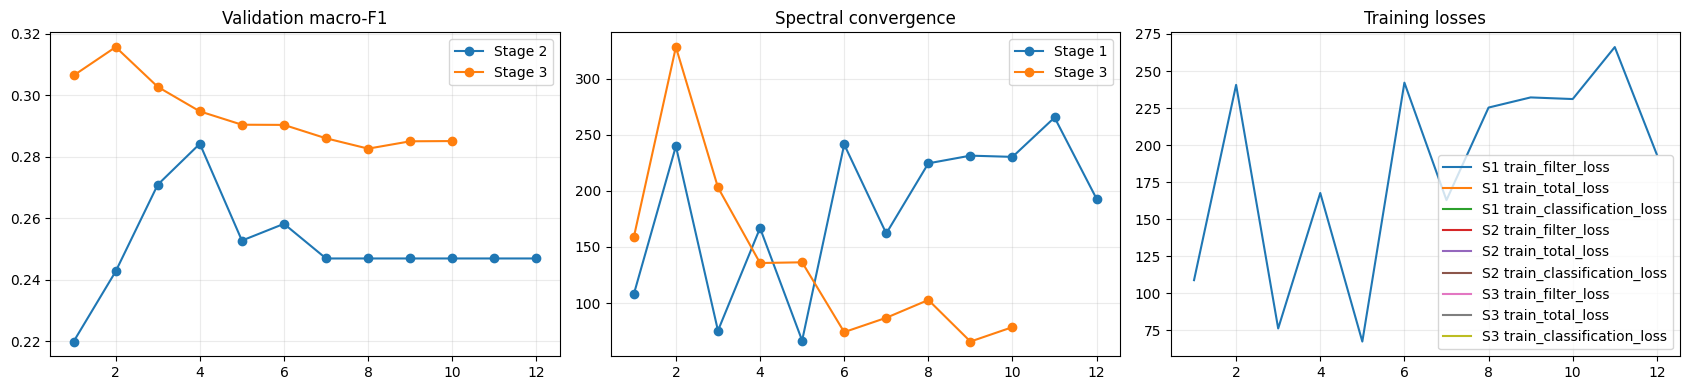

In [10]:
# CELL: training_curves
history_df = pd.DataFrame(HISTORY)
display(history_df)
if not history_df.empty:
    fig, axes = plt.subplots(1, 3, figsize=(17, 4))
    for stage, frame in history_df.groupby("stage"):
        if "val_macro_f1" in frame and frame["val_macro_f1"].notna().any():
            axes[0].plot(frame["epoch"], frame["val_macro_f1"], marker="o", label=f"Stage {stage}")
        if "train_spectral_convergence" in frame and frame["train_spectral_convergence"].notna().any():
            axes[1].plot(frame["epoch"], frame["train_spectral_convergence"], marker="o", label=f"Stage {stage}")
        loss_columns = [c for c in ("train_filter_loss", "train_total_loss",
                                    "train_classification_loss") if c in frame]
        for column in loss_columns:
            axes[2].plot(frame["epoch"], frame[column], label=f"S{stage} {column}")
    for ax, title in zip(axes, ("Validation macro-F1", "Spectral convergence", "Training losses")):
        ax.set_title(title); ax.grid(alpha=0.25); ax.legend()
    plt.tight_layout(); plt.show()


In [11]:
# CELL: evaluation
def evaluate_checkpoint(checkpoint_path, input_mode, name, retune=False):
    checkpoint = load_checkpoint(checkpoint_path, model)
    thresholds = checkpoint.get("thresholds")
    if retune or thresholds is None:
        val_y, val_prob, _ = predict(model, val_loader, DEVICE, input_mode,
                                     CONFIG["sliding_window_eval"],
                                     CONFIG["sliding_hop_seconds"])
        thresholds = tune_thresholds(val_y, val_prob)
    test_y, test_prob, test_snr = predict(
        model, test_loader, DEVICE, input_mode, CONFIG["sliding_window_eval"],
        CONFIG["sliding_hop_seconds"])
    return {"name": name, "input_mode": input_mode,
            **metrics(test_y, test_prob, thresholds)}, (test_y, test_prob, test_snr, thresholds)


evaluation_rows = []
if CONFIG["input_mode"] == "filtered":
    row, _ = evaluate_checkpoint(OUT_DIR / "stage2_best.pt", "filtered",
                                 "Stage 2 mixed / FILTER")
    evaluation_rows.append(row)
    row, _ = evaluate_checkpoint(OUT_DIR / "stage2_best.pt", "scaled_oracle",
                                 "Stage 2 mixed / Scaled Oracle", retune=True)
    evaluation_rows.append(row)
    row, final_outputs = evaluate_checkpoint(OUT_DIR / "stage3_best.pt", "filtered",
                                             "Stage 3 best / FILTER")
    evaluation_rows.append(row)
else:
    row, final_outputs = evaluate_checkpoint(OUT_DIR / "stage2_best.pt",
                                             CONFIG["input_mode"],
                                             f"Baseline / {CONFIG['input_mode']}")
    evaluation_rows.append(row)

evaluation_df = pd.DataFrame(evaluation_rows).set_index("name")
display(evaluation_df)
evaluation_df.to_csv(OUT_DIR / "evaluation_summary.csv")
test_y, test_prob, test_snr, thresholds = final_outputs


,input_mode,macro_f1,micro_f1,mAP
name,,,,
Stage 2 mixed / FILTER,filtered,0.260020,0.290879,0.199868
Stage 2 mixed / Scaled Oracle,scaled_oracle,0.346206,0.373597,0.286271
Stage 3 best / FILTER,filtered,0.293507,0.320201,0.233153


,label,threshold,support,precision,recall,f1,AP
0,Music,0.40,889,0.440143,0.690664,0.537653,0.485991
1,Vehicle,0.40,525,0.389660,0.588571,0.468892,0.433153
9,Siren,0.55,200,0.430693,0.435000,0.432836,0.420247
8,Water,0.40,202,0.295455,0.514851,0.375451,0.266149
11,"Wind instrument, woodwind instrument",0.60,191,0.348259,0.366492,0.357143,0.328809
3,Animal,0.35,393,0.245050,0.503817,0.329725,0.274680
15,Drum,0.40,164,0.282511,0.384146,0.325581,0.289576
4,Musical instrument,0.45,302,0.264770,0.400662,0.318841,0.241751
18,Bowed string instrument,0.35,141,0.204748,0.489362,0.288703,0.208294
10,Fowl,0.40,201,0.231270,0.353234,0.279528,0.209540


,snr_band,samples,macro_f1,micro_f1,mAP
0,"[-5, 0] dB",1301,0.326764,0.355026,0.287467
1,"[5, 10] dB",1316,0.312279,0.335404,0.258479
2,"[15, 20] dB",1289,0.224824,0.262116,0.186852


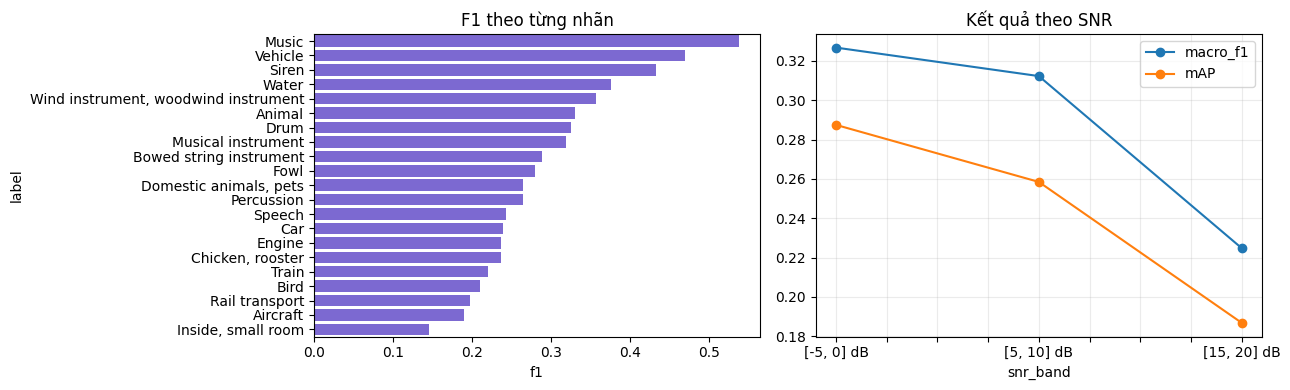

In [12]:
# CELL: detailed_evaluation
test_prediction = test_prob >= thresholds
precision, recall, f1, support = precision_recall_fscore_support(
    test_y, test_prediction, average=None, zero_division=0)
ap = [average_precision_score(test_y[:, i], test_prob[:, i])
      for i in range(len(CLASS_NAMES))]
per_class = pd.DataFrame({
    "label": CLASS_NAMES, "threshold": thresholds, "support": support,
    "precision": precision, "recall": recall, "f1": f1, "AP": ap,
}).sort_values("f1", ascending=False)
display(per_class)
per_class.to_csv(OUT_DIR / "test_per_class.csv", index=False)

snr_bands = [("[-5, 0] dB", -5.0, 0.0), ("[5, 10] dB", 5.0, 10.0),
             ("[15, 20] dB", 15.0, 20.0)]
snr_rows = []
for name, low, high in snr_bands:
    keep = (test_snr >= low) & (test_snr <= high)
    if keep.any():
        snr_rows.append({"snr_band": name, "samples": int(keep.sum()),
                         **metrics(test_y[keep], test_prob[keep], thresholds)})
snr_df = pd.DataFrame(snr_rows)
display(snr_df)
snr_df.to_csv(OUT_DIR / "test_by_snr.csv", index=False)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
sns.barplot(data=per_class, x="f1", y="label", ax=axes[0], color="#7158e2")
axes[0].set_title("F1 theo từng nhãn")
snr_df.plot(x="snr_band", y=["macro_f1", "mAP"], marker="o", ax=axes[1])
axes[1].set_title("Kết quả theo SNR"); axes[1].grid(alpha=0.25)
plt.tight_layout(); plt.show()


In [13]:
# CELL: inference_example
checkpoint = load_checkpoint(OUT_DIR / "best.pt", model)
sample_mix, sample_oracle, sample_scale, sample_target, sample_snr = test_ds[0]
mode = "filtered" if CONFIG["input_mode"] == "filtered" else CONFIG["input_mode"]
reference = reference_for_mode(sample_oracle.unsqueeze(0).to(DEVICE),
                               sample_scale.view(1).to(DEVICE), mode)
with torch.inference_mode():
    logits, estimated, sample_mask, sample_gate = model(
        sample_mix.unsqueeze(0).to(DEVICE), reference, mode)
    if CONFIG["adaptive_gain"] and mode != "mixture":
        mixture_spec = model.stft(sample_mix.unsqueeze(0).to(DEVICE))
        conditional_gain, estimated_snr = model.estimate_conditional_gain(
            estimated, mixture_spec)
probabilities = logits.sigmoid()[0].cpu().numpy()
predicted = [CLASS_NAMES[i] for i in range(21) if probabilities[i] >= thresholds[i]]
expected = [CLASS_NAMES[i] for i in range(21) if sample_target[i] > 0]

print("SNR:", sample_snr, "dB")
print("Nhãn thật:", expected)
print("Dự đoán:", predicted)
print("Cross-band weights:", sample_gate[0].cpu().numpy())
if CONFIG["adaptive_gain"] and mode != "mixture":
    print(f"Conditional Gain: {conditional_gain.item():.3f}x | "
          f"SNR ước lượng: {estimated_snr.item():.2f} dB")


SNR: -5.0 dB
Nhãn thật: ['Music', 'Musical instrument']
Dự đoán: ['Music', 'Musical instrument', 'Wind instrument, woodwind instrument', 'Bowed string instrument']
Cross-band weights: [0.05967879 0.9387341  0.00158706]
Conditional Gain: 2.575x | SNR ước lượng: 10.23 dB
